In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_heart=pd.read_csv("heart.csv")
df_heart.head()
df_heart.info()
df_copy=df_heart.copy()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


In [3]:
df_copy.isnull().sum()
df_copy.drop_duplicates(inplace=True)
df_copy.count()


Age               918
Sex               918
ChestPainType     918
RestingBP         918
Cholesterol       918
FastingBS         918
RestingECG        918
MaxHR             918
ExerciseAngina    918
Oldpeak           918
ST_Slope          918
HeartDisease      918
dtype: int64

Text(0.5, 1.0, 'All numeric values in data')

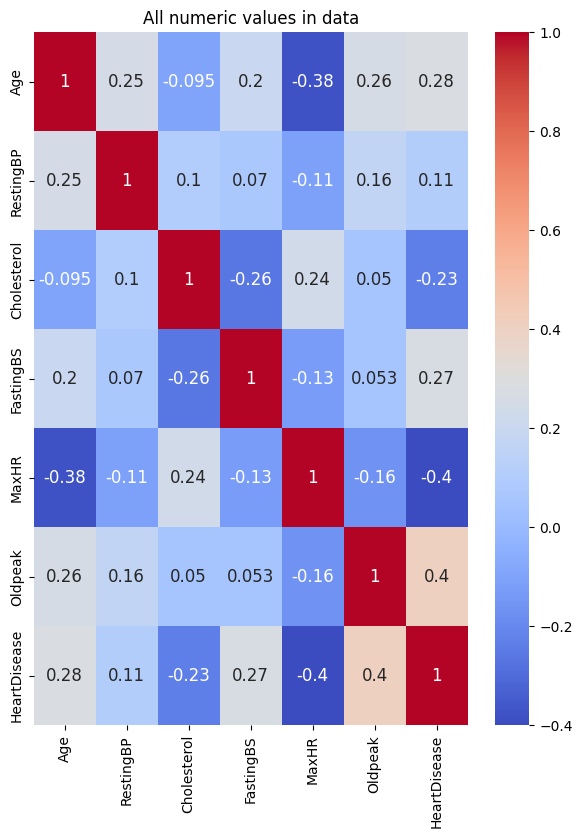

In [4]:
fig=plt.subplots(figsize=(7,9))
sns.heatmap(
    df_copy.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    annot_kws={"size":12}
)
plt.title("All numeric values in data")

In [5]:
df_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB


C:\Users\Dell\AppData\Local\Temp\ipykernel_16076\3072388315.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  str_col=df_copy.select_dtypes(include='object').columns


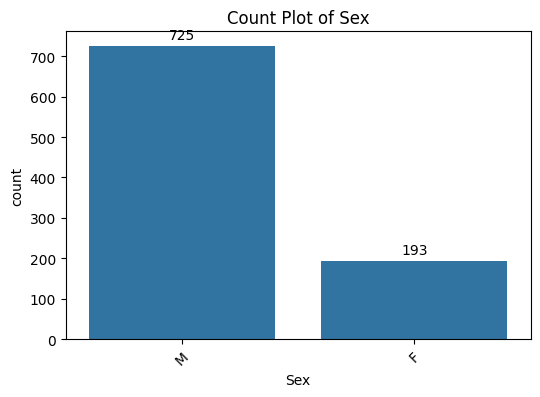

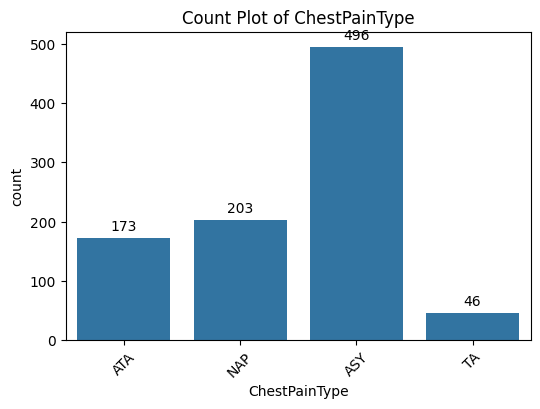

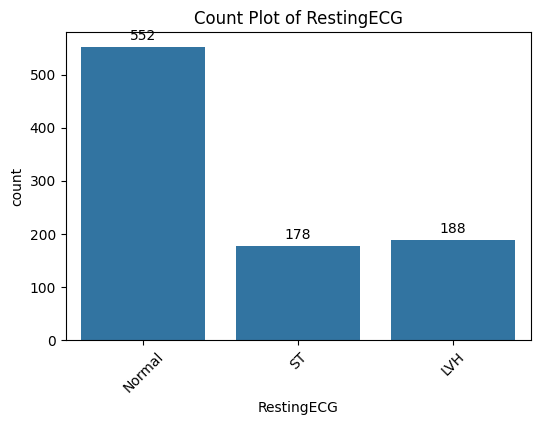

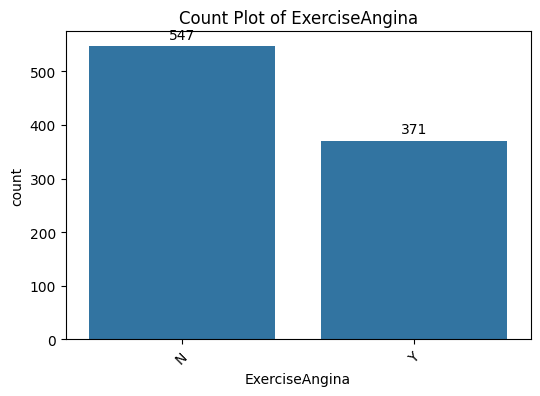

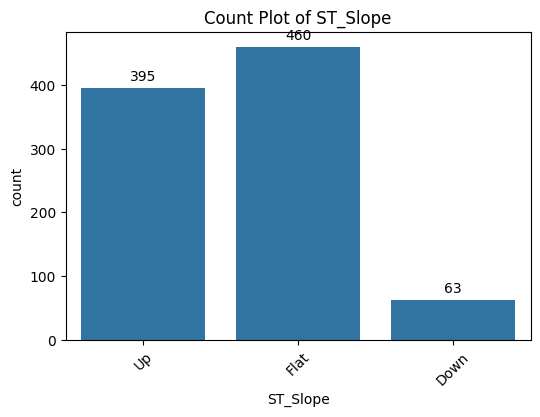

In [6]:
str_col=df_copy.select_dtypes(include='object').columns
str_col

for col in str_col:
    plt.figure(figsize=(6,4))
    
    ax = sns.countplot(x=df_copy[col])
    
    # Add labels at upper-right
    for container in ax.containers:
        ax.bar_label(
            container,
            label_type='edge',   # puts label at edge (top)
            padding=3            # small gap above bar
        )
    
    
    
    plt.title(f"Count Plot of {col}")
    plt.xticks(rotation=45)
    plt.show()

In [7]:
df_copy['Sex'].value_counts()

Sex
M    725
F    193
Name: count, dtype: int64

In [8]:
df_copy['Sex']=df_copy['Sex'].str.strip().str.upper()
df_copy['Sex'].head()

0    M
1    F
2    M
3    F
4    M
Name: Sex, dtype: str

In [9]:
s_map={'M':1,'F':0}
df_copy['Sex']=df_copy['Sex'].replace(s_map)
df_copy.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,0,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,1,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,0,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,1,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [10]:
if 'Sex' in df_copy.columns:
    df_copy['isMale']=df_copy['Sex']
    df_copy.drop('Sex',axis=1,inplace=True)

In [11]:
df_copy.head()

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,isMale
0,40,ATA,140,289,0,Normal,172,N,0.0,Up,0,1
1,49,NAP,160,180,0,Normal,156,N,1.0,Flat,1,0
2,37,ATA,130,283,0,ST,98,N,0.0,Up,0,1
3,48,ASY,138,214,0,Normal,108,Y,1.5,Flat,1,0
4,54,NAP,150,195,0,Normal,122,N,0.0,Up,0,1


In [12]:
df_copy['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

In [13]:
df_copy['ChestPainType']=df_heart['ChestPainType']
df_copy=pd.get_dummies(df_copy,columns=['ChestPainType'],dtype=int)

In [14]:
df_copy.head()

,Age,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,isMale,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,140,289,0,Normal,172,N,0.0,Up,0,1,0,1,0,0
1,49,160,180,0,Normal,156,N,1.0,Flat,1,0,0,0,1,0
2,37,130,283,0,ST,98,N,0.0,Up,0,1,0,1,0,0
3,48,138,214,0,Normal,108,Y,1.5,Flat,1,0,1,0,0,0
4,54,150,195,0,Normal,122,N,0.0,Up,0,1,0,0,1,0


In [15]:
df_copy['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [16]:
df_copy=pd.get_dummies(df_copy,columns=['RestingECG'],dtype=int)

In [17]:
df_copy.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,isMale,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,140,289,0,172,N,0.0,Up,0,1,0,1,0,0,0,1,0
1,49,160,180,0,156,N,1.0,Flat,1,0,0,0,1,0,0,1,0
2,37,130,283,0,98,N,0.0,Up,0,1,0,1,0,0,0,0,1
3,48,138,214,0,108,Y,1.5,Flat,1,0,1,0,0,0,0,1,0
4,54,150,195,0,122,N,0.0,Up,0,1,0,0,1,0,0,1,0


In [18]:
df_copy['ExerciseAngina'].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [19]:
e_map={'N':0,'Y':1}
df_copy['ExerciseAngina']=df_copy['ExerciseAngina'].replace(e_map)
df_copy.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,isMale,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST
0,40,140,289,0,172,0,0.0,Up,0,1,0,1,0,0,0,1,0
1,49,160,180,0,156,0,1.0,Flat,1,0,0,0,1,0,0,1,0
2,37,130,283,0,98,0,0.0,Up,0,1,0,1,0,0,0,0,1
3,48,138,214,0,108,1,1.5,Flat,1,0,1,0,0,0,0,1,0
4,54,150,195,0,122,0,0.0,Up,0,1,0,0,1,0,0,1,0


In [20]:
df_copy['ST_Slope'].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

In [21]:
df_copy=pd.get_dummies(df_copy,columns=['ST_Slope'],dtype=int)

In [22]:
df_copy.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,isMale,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0,0.0,0,1,0,1,0,0,0,1,0,0,0,1
1,49,160,180,0,156,0,1.0,1,0,0,0,1,0,0,1,0,0,1,0
2,37,130,283,0,98,0,0.0,0,1,0,1,0,0,0,0,1,0,0,1
3,48,138,214,0,108,1,1.5,1,0,1,0,0,0,0,1,0,0,1,0
4,54,150,195,0,122,0,0.0,0,1,0,0,1,0,0,1,0,0,0,1


In [23]:
#feature engineering

df_copy['Age'].max()
df_copy['Age'].min()

df_copy['Age_category']=pd.cut(
    df_copy['Age'],
    bins=[28,40,52,64,float('inf')],
    labels=['Young','Mid','Senior','Old']
)



In [24]:
df_copy['cholestrol_range']=pd.cut(
    df_copy['Cholesterol'],
    bins=[0,200,240,600,float('inf')],
    labels=['Normal','Borderline','Risk','Disaster']
)


In [25]:
df_copy['BP_per_age']=df_copy['RestingBP']/df_copy['Age']
df_copy['HR_efficiency']=df_copy['MaxHR']/df_copy['Age']
df_copy['RiskScore']=(
    df_copy['Cholesterol']+
    df_copy['RestingBP']+
    df_copy['Oldpeak']
)

df_copy.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,isMale,ChestPainType_ASY,...,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up,Age_category,cholestrol_range,BP_per_age,HR_efficiency,RiskScore
0,40,140,289,0,172,0,0.0,0,1,0,...,1,0,0,0,1,Young,Risk,3.500000,4.300000,429.0
1,49,160,180,0,156,0,1.0,1,0,0,...,1,0,0,1,0,Mid,Normal,3.265306,3.183673,341.0
2,37,130,283,0,98,0,0.0,0,1,0,...,0,1,0,0,1,Young,Risk,3.513514,2.648649,413.0
3,48,138,214,0,108,1,1.5,1,0,1,...,1,0,0,1,0,Mid,Borderline,2.875000,2.250000,353.5
4,54,150,195,0,122,0,0.0,0,1,0,...,1,0,0,0,1,Senior,Normal,2.777778,2.259259,345.0


In [26]:
df_copy=pd.get_dummies(df_copy,columns=['Age_category','cholestrol_range'],dtype=int)

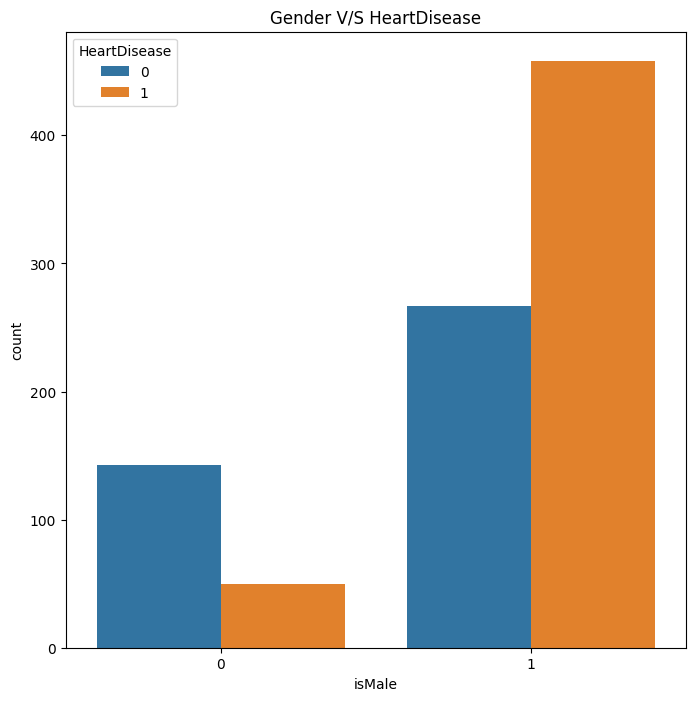

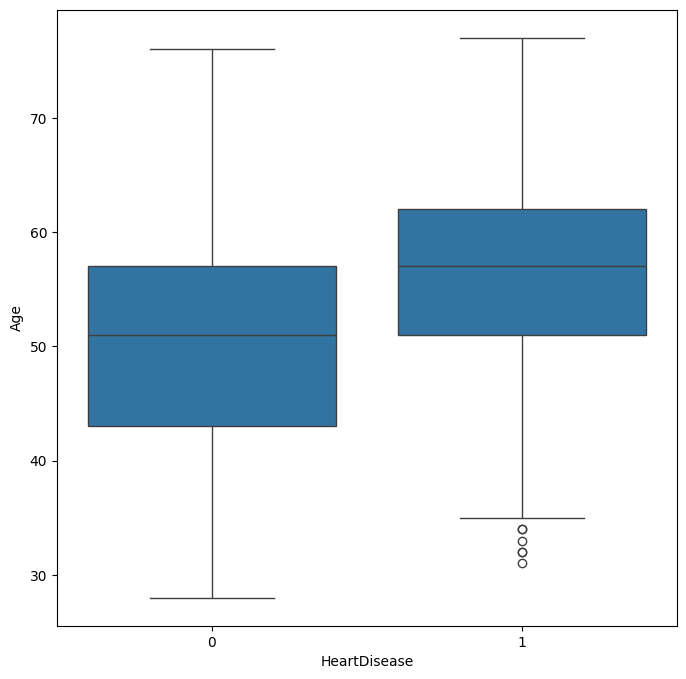

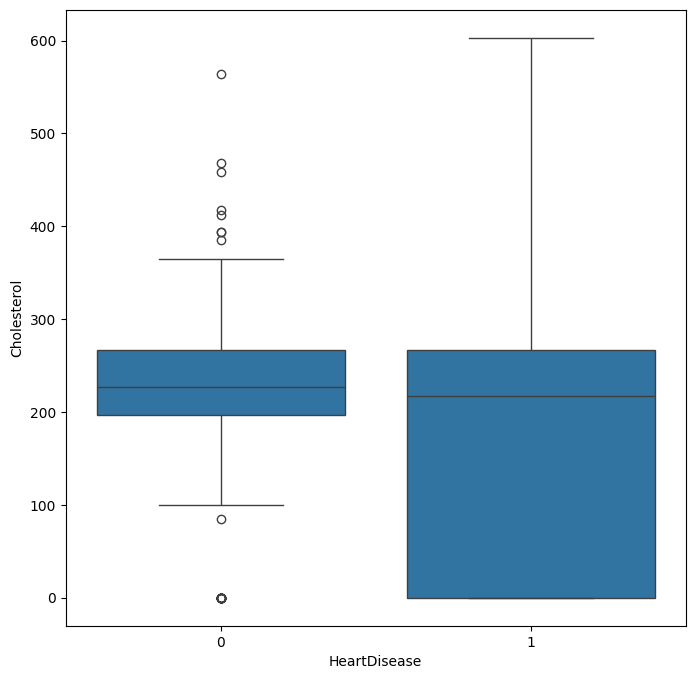

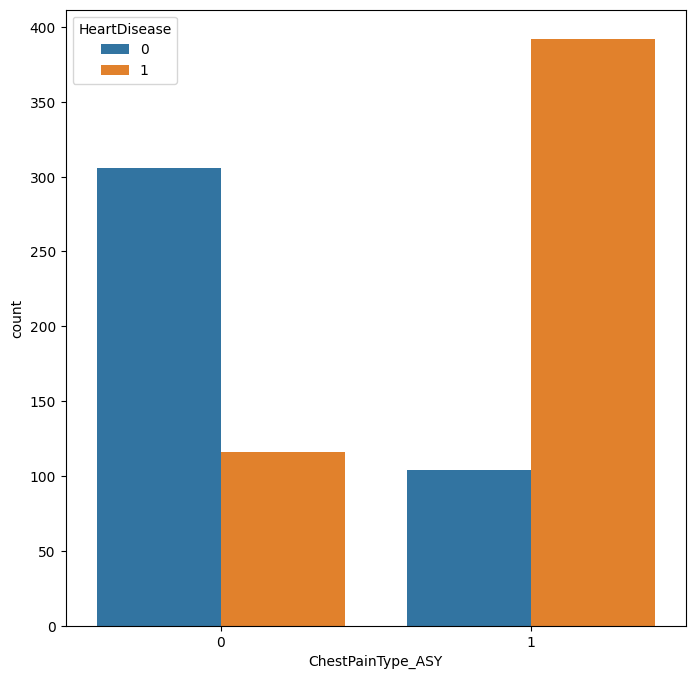

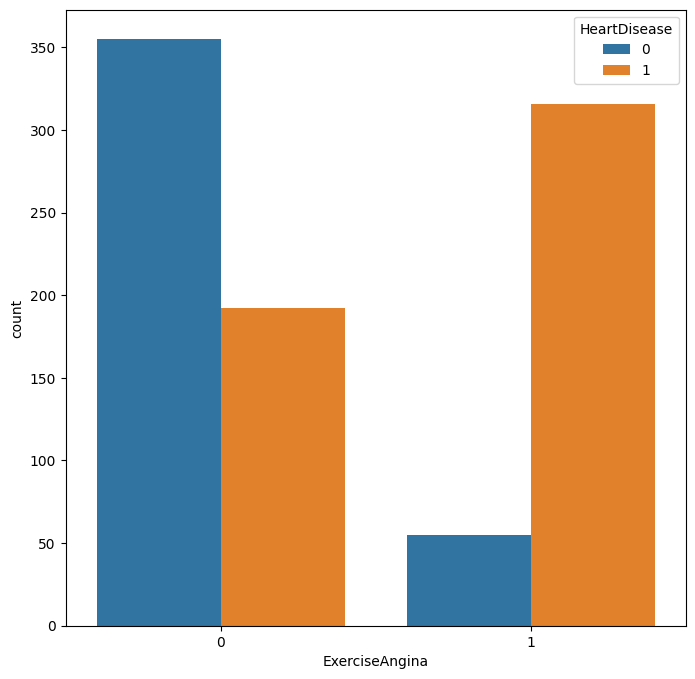

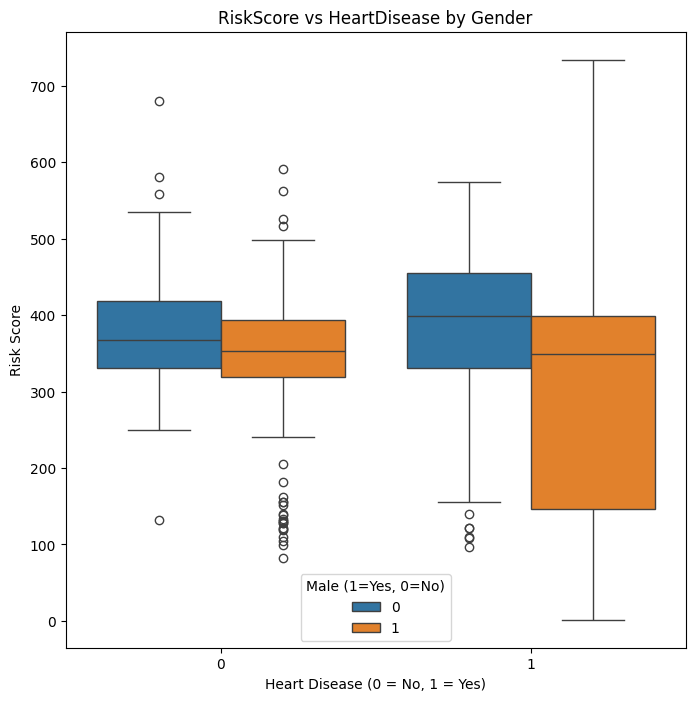

In [27]:
## Feature vs Target Analysis

fig=plt.subplots(figsize=(8,8))
sns.countplot(
    x='isMale',
    hue='HeartDisease',
    data=df_copy
)
plt.title('Gender V/S HeartDisease')

fig=plt.subplots(figsize=(8,8))

sns.boxplot(
    x='HeartDisease',
    y='Age',
    data=df_copy
)

fig=plt.subplots(figsize=(8,8))

sns.boxplot(
    x='HeartDisease',
    y='Cholesterol',
    data=df_copy
)

fig=plt.subplots(figsize=(8,8))

sns.countplot(
    x='ChestPainType_ASY',
    hue='HeartDisease',
    data=df_copy
)

fig=plt.subplots(figsize=(8,8))
sns.countplot(
    x='ExerciseAngina',
    hue='HeartDisease',
    data=df_copy
)

fig=plt.subplots(figsize=(8,8))
sns.boxplot(
    x='HeartDisease',
    y='RiskScore',
    hue='isMale',
    data=df_copy,
   
)
plt.title("RiskScore vs HeartDisease by Gender")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Risk Score")
plt.legend(title="Male (1=Yes, 0=No)")


insights
- Older individuals have higher heart disease risk  
- High cholesterol and BP increase risk  
- Certain chest pain types strongly correlate with disease  
- Exercise-induced angina shows higher disease probability  
- Engineered features like RiskScore help in understanding patterns  
- Exercise-induced angina strongly indicates heart disease
- Patients with HeartDisease = 1 have higher RiskScore